# 1. Über den Datensatz

Dieser Datensatz enthält die 1.000 beliebtesten Filme auf IMDb zwischen 2006 und 2016. Jede Zeile repräsentiert einen einzelnen Film. Der Datensatz besteht aus Variablen, die Filmeigenschaften wie rank, title, genre, description, director, actors, year, runtime, rating, votes, revenue und metascore enthalten.

<table style='text-align: left; margin-left: 0;'>
  <tr>
    <th>Spaltenname</th>
    <th>Beschreibung</th>
  </tr>
  <tr>
    <td><strong>Rank</strong></td>
    <td>Positionsnummer im Datensatz</td>
  </tr>
  <tr>
    <td><strong>Title</strong></td>
    <td>Filmtitel</td>
  </tr>
  <tr>
    <td><strong>Genre</strong></td>
    <td>Genre oder Genres des Films</td>
  </tr>
  <tr>
    <td><strong>Description</strong></td>
    <td>Kurzbeschreibung des Films</td>
  </tr>
  <tr>
    <td><strong>Director</strong></td>
    <td>Regisseur des Films</td>
  </tr>
  <tr>
    <td><strong>Actors</strong></td>
    <td>Hauptdarsteller des Films</td>
  </tr>
  <tr>
    <td><strong>Year</strong></td>
    <td>Erscheinungsjahr des Films</td>
  </tr>
  <tr>
    <td><strong>Runtime</strong></td>
    <td>Laufzeit des Films</td>
  </tr>
  <tr>
    <td><strong>Rating</strong></td>
    <td>IMDb-Nutzerbewertung</td>
  </tr>
  <tr>
    <td><strong>Votes</strong></td>
    <td>Gesamtzahl der abgegebenen Stimmen</td>
  </tr>
  <tr>
    <td><strong>Revenue</strong></td>
    <td>Box-Office-Umsatz des Films</td>
  </tr>
  <tr>
    <td><strong>Metascore</strong></td>
    <td>Metascore-Bewertung basierend auf Kritiken</td>
  </tr>
</table>

# 2. Importieren der Bibliotheken

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
pd.set_option('display.max_columns', None)  
plt.rcParams['figure.figsize'] = (10, 6)  
plt.style.use('ggplot')  
warnings.filterwarnings('ignore')

# 3. Laden des Datensatzes

In [3]:
df = pd.read_csv('../data/imdb_raw.csv')

df

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0


In [4]:
df_copy = df.copy()

# 4. Überblick über den Datensatz

In [5]:
df.sample()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
445,446,Silent Hill,"Adventure,Horror,Mystery","A woman, Rose, goes in search for her adopted ...",Christophe Gans,"Radha Mitchell, Laurie Holden, Sean Bean,Debor...",2006,125,6.6,184152,46.98,NaN


In [6]:
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [7]:
df.tail()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


In [8]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [12]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


<div style='background-color: #ffebee; border-left: 5px solid #f44336; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #c62828;'>🧾 Ergebnisse</h3>
  <ul>
    <li>Im Datensatz befindet sich eine für die Analyse unnötige Spalte.</li>
    <li>Es bestehen nicht standardisierte Benennungen in den Spaltennamen.</li>
    <li>Der Datensatz enthält fehlende Werte.</li> 
  </ul>
</div>

<div style='background-color: #e3f2fd; border-left: 5px solid #2196F3; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #1565c0;'>🎯 Entscheidung</h3>
  <ul>
    <li><strong>Rank</strong> wird aus dem Datensatz entfernt, und nach den notwendigen Anpassungen wird eine explorative Datenanalyse auf Spaltenebene durchgeführt.</li>
  </ul>
</div>

# 5. Datenbereinigung und Vorverarbeitung

In [13]:
df = df.drop(columns='Rank')

df

,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0
...,...,...,...,...,...,...,...,...,...,...,...
995,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0


In [14]:
df.columns

Index(['Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')

In [15]:
df.columns = ['title', 'genre', 'description', 'director', 'actors', 'year', 'runtime', 'rating', 'votes', 'revenue', 'metascore']

df.columns

Index(['title', 'genre', 'description', 'director', 'actors', 'year',
       'runtime', 'rating', 'votes', 'revenue', 'metascore'],
      dtype='object')

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahmen</h3>
  <ul>
    <li><strong>Rank</strong> wurde aus dem Datensatz entfernt.</li>
    <li>Die Spaltennamen wurden standardisiert.</li>
  </ul>
</div>

## 5.1. Title

In [16]:
df[['title']].sample(5)

,title
59,Sully
992,Take Me Home Tonight
627,The Escort
554,Colonia
652,Insidious


In [17]:
df.title.nunique()

999

In [18]:
df.title.unique()[:10]

array(['Guardians of the Galaxy', 'Prometheus', 'Split', 'Sing',
       'Suicide Squad', 'The Great Wall', 'La La Land', 'Mindhorn',
       'The Lost City of Z', 'Passengers'], dtype=object)

In [19]:
df.title.value_counts()

title
The Host                   2
Guardians of the Galaxy    1
The Hurt Locker            1
The Daughter               1
Pineapple Express          1
                          ..
The Fault in Our Stars     1
Blended                    1
Fast & Furious             1
Looper                     1
Nine Lives                 1
Name: count, Length: 999, dtype: int64

In [20]:
df[df.duplicated(subset='title', keep=False)]

,title,genre,description,director,actors,year,runtime,rating,votes,revenue,metascore
239,The Host,"Action,Adventure,Romance",When an unseen enemy threatens mankind by taki...,Andrew Niccol,"Saoirse Ronan, Max Irons, Jake Abel, Diane Kruger",2013,125,5.9,96852,26.62,35.0
632,The Host,"Comedy,Drama,Horror",A monster emerges from Seoul's Han River and f...,Bong Joon Ho,"Kang-ho Song, Hee-Bong Byun, Hae-il Park, Doon...",2006,120,7.0,73491,2.20,85.0


In [21]:
df.title = df.title.str.replace(r'\s+', ' ', regex=True).str.strip()

df.title

0      Guardians of the Galaxy
1                   Prometheus
2                        Split
3                         Sing
4                Suicide Squad
                ...           
995       Secret in Their Eyes
996            Hostel: Part II
997     Step Up 2: The Streets
998               Search Party
999                 Nine Lives
Name: title, Length: 1000, dtype: object

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahme</h3>
  <ul>
    <li>In der entsprechenden Spalte wurde eine grundlegende Textbereinigung durchgeführt.</li>
  </ul>
</div>

## 5.2. Genre

In [22]:
df[['genre']].sample(5)

,genre
868,"Comedy,Family"
571,"Animation,Comedy,Family"
754,"Biography,Drama,History"
420,"Action,Drama,Thriller"
538,"Crime,Drama,Thriller"


In [23]:
df.genre.nunique()

207

In [24]:
df.genre.unique()[:10]

array(['Action,Adventure,Sci-Fi', 'Adventure,Mystery,Sci-Fi',
       'Horror,Thriller', 'Animation,Comedy,Family',
       'Action,Adventure,Fantasy', 'Comedy,Drama,Music', 'Comedy',
       'Action,Adventure,Biography', 'Adventure,Drama,Romance',
       'Adventure,Family,Fantasy'], dtype=object)

In [25]:
df.genre.value_counts()

genre
Action,Adventure,Sci-Fi    50
Drama                      48
Comedy,Drama,Romance       35
Comedy                     32
Drama,Romance              31
                           ..
Action,Comedy,Family        1
Action,Crime,Fantasy        1
Comedy,Mystery              1
Adventure,Comedy,Horror     1
Comedy,Family,Fantasy       1
Name: count, Length: 207, dtype: int64

In [26]:
df.genre = df.genre.str.replace(r'\s*,\s*', ', ', regex=True).str.strip()

df.genre

0       Action, Adventure, Sci-Fi
1      Adventure, Mystery, Sci-Fi
2                Horror, Thriller
3       Animation, Comedy, Family
4      Action, Adventure, Fantasy
                  ...            
995         Crime, Drama, Mystery
996                        Horror
997         Drama, Music, Romance
998             Adventure, Comedy
999       Comedy, Family, Fantasy
Name: genre, Length: 1000, dtype: object

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahme</h3>
  <ul>
    <li>In der entsprechenden Spalte wurde eine grundlegende Textbereinigung durchgeführt.</li>
  </ul>
</div>

## 5.3. Description

In [27]:
df[['description']].sample(5)

,description
439,A successful singer-songwriter hatches a plan ...
342,While on a tour of the White House with his yo...
178,Lorraine and Ed Warren travel to north London ...
403,When a criminal mastermind uses a trio of orph...
337,"A young, talented, and lonely long-distance ru..."


In [28]:
df.description.nunique()

1000

In [29]:
df.description.unique()[:10]

array(['A group of intergalactic criminals are forced to work together to stop a fanatical warrior from taking control of the universe.',
       'Following clues to the origin of mankind, a team finds a structure on a distant moon, but they soon realize they are not alone.',
       'Three girls are kidnapped by a man with a diagnosed 23 distinct personalities. They must try to escape before the apparent emergence of a frightful new 24th.',
       "In a city of humanoid animals, a hustling theater impresario's attempt to save his theater with a singing competition becomes grander than he anticipates even as its finalists' find that their lives will never be the same.",
       'A secret government agency recruits some of the most dangerous incarcerated super-villains to form a defensive task force. Their first mission: save the world from the apocalypse.',
       'European mercenaries searching for black powder become embroiled in the defense of the Great Wall of China against a horde of

In [30]:
df.description = df.description.str.replace('"', "'", regex=False).str.replace(r'\s+', ' ', regex=True).str.strip()

df.description

0      A group of intergalactic criminals are forced ...
1      Following clues to the origin of mankind, a te...
2      Three girls are kidnapped by a man with a diag...
3      In a city of humanoid animals, a hustling thea...
4      A secret government agency recruits some of th...
                             ...                        
995    A tight-knit team of rising investigators, alo...
996    Three American college students studying abroa...
997    Romantic sparks occur between two dance studen...
998    A pair of friends embark on a mission to reuni...
999    A stuffy businessman finds himself trapped ins...
Name: description, Length: 1000, dtype: object

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahme</h3>
  <ul>
    <li>In der entsprechenden Spalte wurde eine grundlegende Textbereinigung durchgeführt.</li>
  </ul>
</div>

## 5.4. Director

In [31]:
df[['director']].sample(5)

,director
456,Anne Fletcher
738,Terrence Malick
114,David Yates
15,Chris Renaud
534,Terence Davies


In [32]:
df.director.nunique()

644

In [33]:
df.director.unique()[:10]

array(['James Gunn', 'Ridley Scott', 'M. Night Shyamalan',
       'Christophe Lourdelet', 'David Ayer', 'Yimou Zhang',
       'Damien Chazelle', 'Sean Foley', 'James Gray', 'Morten Tyldum'],
      dtype=object)

In [34]:
df.director.value_counts()

director
Ridley Scott          8
David Yates           6
M. Night Shyamalan    6
Paul W.S. Anderson    6
Michael Bay           6
                     ..
Lee Toland Krieger    1
Gillies MacKinnon     1
Peter Atencio         1
James Mangold         1
Scot Armstrong        1
Name: count, Length: 644, dtype: int64

In [35]:
df.director = df.director.str.replace(r'\s+', ' ', regex=True).str.strip()

df.director

0                James Gunn
1              Ridley Scott
2        M. Night Shyamalan
3      Christophe Lourdelet
4                David Ayer
               ...         
995               Billy Ray
996                Eli Roth
997              Jon M. Chu
998          Scot Armstrong
999        Barry Sonnenfeld
Name: director, Length: 1000, dtype: object

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahme</h3>
  <ul>
    <li>In der entsprechenden Spalte wurde eine grundlegende Textbereinigung durchgeführt.</li>
  </ul>
</div>

## 5.5. Actors

In [36]:
df[['actors']].sample(5)

,actors
837,"Adam Sandler, John Turturro, Emmanuelle Chriqu..."
150,"Mark Rylance, Ruby Barnhill, Penelope Wilton,J..."
561,"Jane Levy, Shiloh Fernandez, Jessica Lucas, Lo..."
267,"Tom Hanks, Halle Berry, Hugh Grant, Hugo Weaving"
551,"Ruth Negga, Joel Edgerton, Will Dalton, Dean M..."


In [37]:
df.actors.nunique()

996

In [38]:
df.actors.unique()[:10]

array(['Chris Pratt, Vin Diesel, Bradley Cooper, Zoe Saldana',
       'Noomi Rapace, Logan Marshall-Green, Michael Fassbender, Charlize Theron',
       'James McAvoy, Anya Taylor-Joy, Haley Lu Richardson, Jessica Sula',
       'Matthew McConaughey,Reese Witherspoon, Seth MacFarlane, Scarlett Johansson',
       'Will Smith, Jared Leto, Margot Robbie, Viola Davis',
       'Matt Damon, Tian Jing, Willem Dafoe, Andy Lau',
       'Ryan Gosling, Emma Stone, Rosemarie DeWitt, J.K. Simmons',
       'Essie Davis, Andrea Riseborough, Julian Barratt,Kenneth Branagh',
       'Charlie Hunnam, Robert Pattinson, Sienna Miller, Tom Holland',
       'Jennifer Lawrence, Chris Pratt, Michael Sheen,Laurence Fishburne'],
      dtype=object)

In [39]:
df.actors.value_counts()

actors
Jennifer Lawrence, Josh Hutcherson, Liam Hemsworth, Woody Harrelson    2
Daniel Radcliffe, Emma Watson, Rupert Grint, Michael Gambon            2
Shia LaBeouf, Megan Fox, Josh Duhamel, Tyrese Gibson                   2
Gerard Butler, Aaron Eckhart, Morgan Freeman,Angela Bassett            2
Chris Pratt, Vin Diesel, Bradley Cooper, Zoe Saldana                   1
                                                                      ..
Alexi Pappas, Chase Offerle, Rachel Dratch, Andy Buckley               1
Shailene Woodley, Ansel Elgort, Nat Wolff, Laura Dern                  1
Adam Sandler, Drew Barrymore, Wendi McLendon-Covey, Kevin Nealon       1
Vin Diesel, Paul Walker, Michelle Rodriguez, Jordana Brewster          1
Kevin Spacey, Jennifer Garner, Robbie Amell,Cheryl Hines               1
Name: count, Length: 996, dtype: int64

In [40]:
df[df.duplicated(subset='actors', keep=False)]

,title,genre,description,director,actors,year,runtime,rating,votes,revenue,metascore
114,Harry Potter and the Deathly Hallows: Part 2,"Adventure, Drama, Fantasy","Harry, Ron and Hermione search for Voldemort's...",David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, M...",2011,130,8.1,590595,380.96,87.0
212,Transformers,"Action, Adventure, Sci-Fi",An ancient struggle between two Cybertronian r...,Michael Bay,"Shia LaBeouf, Megan Fox, Josh Duhamel, Tyrese ...",2007,144,7.1,531112,318.76,61.0
408,The Hunger Games: Mockingjay - Part 2,"Action, Adventure, Sci-Fi",As the war of Panem escalates to the destructi...,Francis Lawrence,"Jennifer Lawrence, Josh Hutcherson, Liam Hemsw...",2015,137,6.6,202380,281.67,65.0
424,London Has Fallen,"Action, Crime, Drama","In London for the Prime Minister's funeral, Mi...",Babak Najafi,"Gerard Butler, Aaron Eckhart, Morgan Freeman,A...",2016,99,5.9,100702,62.40,28.0
453,Olympus Has Fallen,"Action, Thriller",Disgraced Secret Service agent (and former pre...,Antoine Fuqua,"Gerard Butler, Aaron Eckhart, Morgan Freeman,A...",2013,119,6.5,214994,98.90,41.0
473,Harry Potter and the Half-Blood Prince,"Adventure, Family, Fantasy",As Harry Potter begins his sixth year at Hogwa...,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, M...",2009,153,7.5,351059,301.96,78.0
680,The Hunger Games: Mockingjay - Part 1,"Action, Adventure, Sci-Fi",Katniss Everdeen is in District 13 after she s...,Francis Lawrence,"Jennifer Lawrence, Josh Hutcherson, Liam Hemsw...",2014,123,6.7,331902,337.10,64.0
710,Transformers: Revenge of the Fallen,"Action, Adventure, Sci-Fi",Sam Witwicky leaves the Autobots behind for a ...,Michael Bay,"Shia LaBeouf, Megan Fox, Josh Duhamel, Tyrese ...",2009,150,6.0,335757,402.08,35.0


In [41]:
df.actors = df.actors.str.replace(r'\s*,\s*', ', ', regex=True).str.strip()

df.actors

0      Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...
1      Noomi Rapace, Logan Marshall-Green, Michael Fa...
2      James McAvoy, Anya Taylor-Joy, Haley Lu Richar...
3      Matthew McConaughey, Reese Witherspoon, Seth M...
4      Will Smith, Jared Leto, Margot Robbie, Viola D...
                             ...                        
995    Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...
996    Lauren German, Heather Matarazzo, Bijou Philli...
997    Robert Hoffman, Briana Evigan, Cassie Ventura,...
998    Adam Pally, T.J. Miller, Thomas Middleditch, S...
999    Kevin Spacey, Jennifer Garner, Robbie Amell, C...
Name: actors, Length: 1000, dtype: object

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahme</h3>
  <ul>
    <li>In der entsprechenden Spalte wurde eine grundlegende Textbereinigung durchgeführt.</li>
  </ul>
</div>

## 5.6. Year

In [42]:
df[['year']].sample(5)

,year
645,2008
718,2014
753,2012
998,2014
728,2010


In [43]:
df.year.min()

2006

In [44]:
df.year.max()

2016

In [45]:
df.year.describe()

count    1000.000000
mean     2012.783000
std         3.205962
min      2006.000000
25%      2010.000000
50%      2014.000000
75%      2016.000000
max      2016.000000
Name: year, dtype: float64

## 5.7. Runtime

In [46]:
df[['runtime']].sample(5)

,runtime
631,112
779,108
33,108
190,133
343,102


In [47]:
df.runtime.min()

66

In [48]:
df.runtime.max()

191

In [49]:
df.runtime.describe()

count    1000.000000
mean      113.172000
std        18.810908
min        66.000000
25%       100.000000
50%       111.000000
75%       123.000000
max       191.000000
Name: runtime, dtype: float64

## 5.8. Rating

In [50]:
df[['rating']].sample(5)

,rating
181,6.8
659,6.7
493,5.3
50,8.1
551,7.1


In [51]:
df.rating.min()

1.9

In [52]:
df.rating.max()

9.0

In [53]:
df.rating.describe()

count    1000.000000
mean        6.723200
std         0.945429
min         1.900000
25%         6.200000
50%         6.800000
75%         7.400000
max         9.000000
Name: rating, dtype: float64

## 5.9. Votes

In [54]:
df[['votes']].sample(5)

,votes
842,137117
683,112313
344,406219
408,202380
246,382910


In [55]:
df.votes.min()

61

In [56]:
df.votes.max()

1791916

In [57]:
df.votes.describe()

count    1.000000e+03
mean     1.698083e+05
std      1.887626e+05
min      6.100000e+01
25%      3.630900e+04
50%      1.107990e+05
75%      2.399098e+05
max      1.791916e+06
Name: votes, dtype: float64

## 5.10. Revenue

In [58]:
df[['revenue']].sample(5)

,revenue
648,0.03
557,55.94
724,176.59
748,34.90
868,52.69


In [59]:
df.revenue.isna().sum()

np.int64(128)

In [60]:
df.revenue.min()

0.0

In [61]:
df.revenue.max()

936.63

In [62]:
df.revenue.describe()

count    872.000000
mean      82.956376
std      103.253540
min        0.000000
25%       13.270000
50%       47.985000
75%      113.715000
max      936.630000
Name: revenue, dtype: float64

In [63]:
df[df.revenue == 0]

,title,genre,description,director,actors,year,runtime,rating,votes,revenue,metascore
231,A Kind of Murder,"Crime, Drama, Thriller","In 1960s New York, Walter Stackhouse is a succ...",Andy Goddard,"Patrick Wilson, Jessica Biel, Haley Bennett, V...",2016,95,5.2,3305,0.0,50.0


In [64]:
df.revenue = df.revenue.replace(0, np.nan)

df.revenue

0      333.13
1      126.46
2      138.12
3      270.32
4      325.02
        ...  
995       NaN
996     17.54
997     58.01
998       NaN
999     19.64
Name: revenue, Length: 1000, dtype: float64

In [65]:
df.revenue.isna().sum()

np.int64(129)

In [66]:
df.revenue.describe()

count    871.000000
mean      83.051619
std      103.274531
min        0.010000
25%       13.350000
50%       48.020000
75%      113.720000
max      936.630000
Name: revenue, dtype: float64

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>✅ Durchgeführte Maßnahme</h3>
  <ul>
    <li>Der Wert 0, der in der entsprechenden Spalte als möglicher Datenfehler bewertet wurde, wurde als fehlender Wert neu klassifiziert.</li>
  </ul>
</div>

## 5.11. Metascore

In [67]:
df[['metascore']].sample(5)

,metascore
670,42.0
328,79.0
127,58.0
840,40.0
888,53.0


In [68]:
df.metascore.isna().sum()

np.int64(64)

In [69]:
df.metascore.min()

11.0

In [70]:
df.metascore.max()

100.0

In [71]:
df.metascore.describe()

count    936.000000
mean      58.985043
std       17.194757
min       11.000000
25%       47.000000
50%       59.500000
75%       72.000000
max      100.000000
Name: metascore, dtype: float64

# 6. Analiz ve Görselleştirme

In [72]:
df.votes.describe()

count    1.000000e+03
mean     1.698083e+05
std      1.887626e+05
min      6.100000e+01
25%      3.630900e+04
50%      1.107990e+05
75%      2.399098e+05
max      1.791916e+06
Name: votes, dtype: float64

In [73]:
top100 = df[df.votes >= 240000].sort_values('rating', ascending=False)[:100].reset_index(drop=True)

top100

,title,genre,description,director,actors,year,runtime,rating,votes,revenue,metascore
0,The Dark Knight,"Action, Crime, Drama",When the menace known as the Joker wreaks havo...,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",2008,152,9.0,1791916,533.32,82.0
1,Inception,"Action, Adventure, Sci-Fi","A thief, who steals corporate secrets through ...",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellen...",2010,148,8.8,1583625,292.57,74.0
2,Interstellar,"Adventure, Drama, Sci-Fi",A team of explorers travel through a wormhole ...,Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch...",2014,169,8.6,1047747,187.99,74.0
3,The Intouchables,"Biography, Comedy, Drama",After he becomes a quadriplegic from a paragli...,Olivier Nakache,"François Cluzet, Omar Sy, Anne Le Ny, Audrey F...",2011,112,8.6,557965,13.18,57.0
4,The Departed,"Crime, Drama, Thriller",An undercover cop and a mole in the police att...,Martin Scorsese,"Leonardo DiCaprio, Matt Damon, Jack Nicholson,...",2006,151,8.5,937414,132.37,85.0
...,...,...,...,...,...,...,...,...,...,...,...
95,X: First Class,"Action, Adventure, Sci-Fi","In 1962, the United States government enlists ...",Matthew Vaughn,"James McAvoy, Michael Fassbender, Jennifer Law...",2011,132,7.8,550011,146.41,65.0
96,The Big Short,"Biography, Comedy, Drama",Four denizens in the world of high-finance pre...,Adam McKay,"Christian Bale, Steve Carell, Ryan Gosling, Br...",2015,130,7.8,246360,70.24,81.0
97,Kingsman: The Secret Service,"Action, Adventure, Comedy","A spy organization recruits an unrefined, but ...",Matthew Vaughn,"Colin Firth, Taron Egerton, Samuel L. Jackson,...",2014,129,7.7,440209,128.25,58.0
98,Midnight in Paris,"Comedy, Fantasy, Romance",While on a trip to Paris with his fiancée's fa...,Woody Allen,"Owen Wilson, Rachel McAdams, Kathy Bates, Kurt...",2011,94,7.7,320323,56.82,81.0


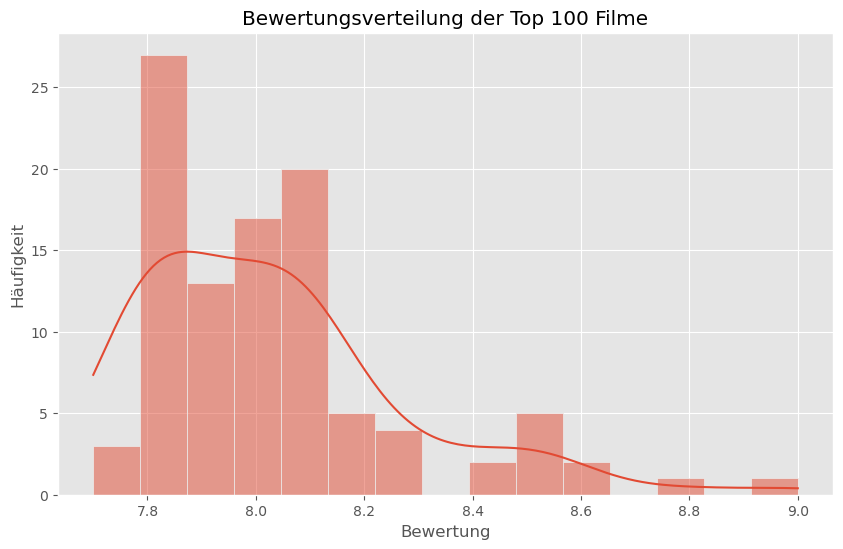

In [74]:
sns.histplot(top100.rating, bins=15, kde=True)

plt.title('Bewertungsverteilung der Top 100 Filme')
plt.xlabel('Bewertung')
plt.ylabel('Häufigkeit')

plt.show()

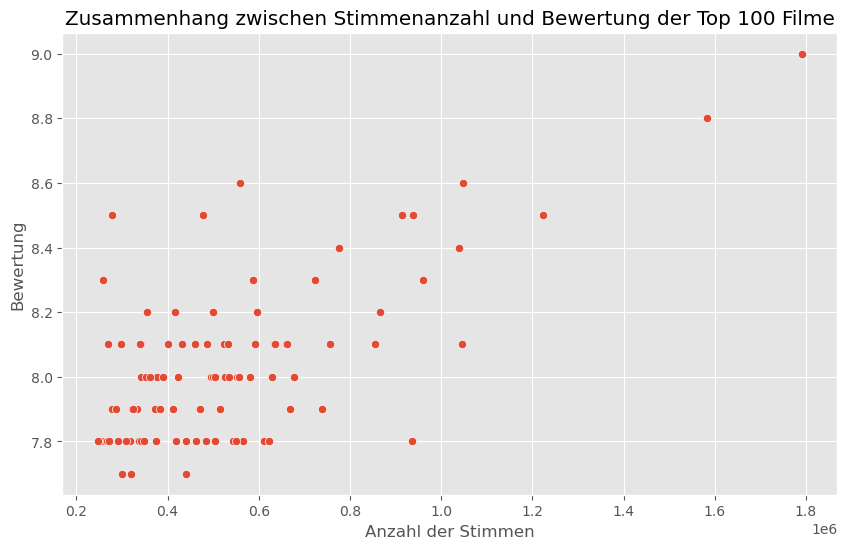

In [75]:
sns.scatterplot(x=top100.votes, y=top100.rating)

plt.title('Zusammenhang zwischen Stimmenanzahl und Bewertung der Top 100 Filme')
plt.xlabel('Anzahl der Stimmen')
plt.ylabel('Bewertung')

plt.show()

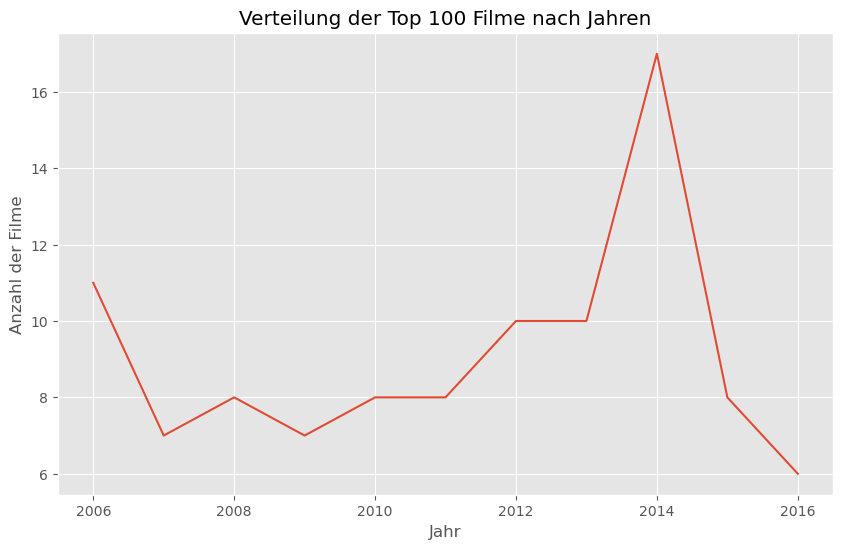

In [76]:
year_counts = top100.year.value_counts().sort_index()

sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title('Verteilung der Top 100 Filme nach Jahren')
plt.xlabel('Jahr')
plt.ylabel('Anzahl der Filme')

plt.show()

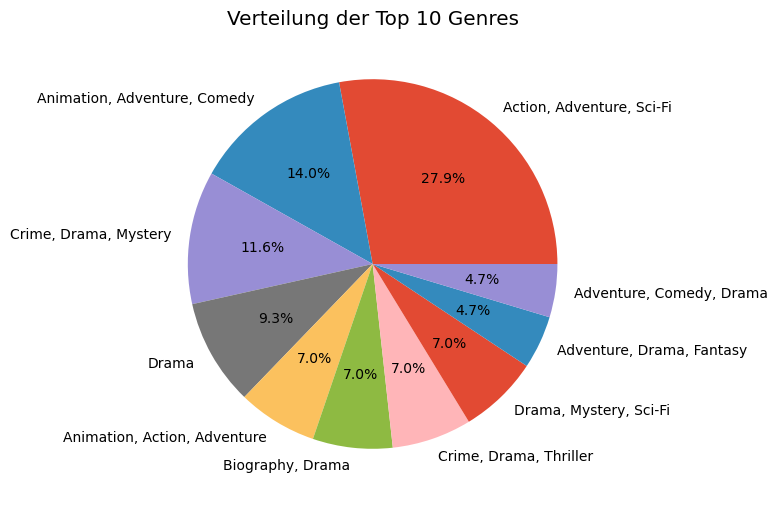

In [77]:
top10_genre = top100.genre.value_counts().head(10)

plt.pie(top10_genre.values, labels=top10_genre.index, autopct='%1.1f%%')

plt.title('Verteilung der Top 10 Genres')

plt.show()

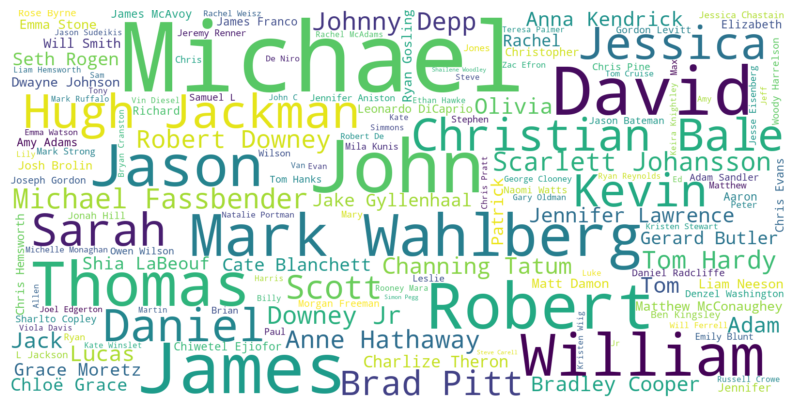

In [78]:
from wordcloud import WordCloud

text = ' '.join(df.actors)

wordcloud = WordCloud(width=1600, height=800, background_color='white', colormap='viridis', max_words=150, max_font_size=200, random_state=42).generate(text)

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.show()

<div style='background-color: #e8f5e9; border-left: 5px solid #4CAF50; padding: 15px; margin: 10px 0;'>
  <h3 style='margin-top: 0; color: #2e7d32;'>📊 Ergebnisse</h3>
  <ul>
    <li>Es wurde beobachtet, dass sich die Bewertungen der Filme im Elite-Segment in einem engen Bereich konzentrieren und das allgemeine Bewertungsniveau hoch ist.</li>
    <li>Es wurde keine starke lineare Beziehung zwischen Stimmenanzahl und Bewertung festgestellt, was darauf hindeutet, dass hohe Popularität nicht immer höhere Bewertungen bedeutet.</li>
    <li>Die Verteilung der Filme nach Jahren zeigt Konzentrationen in bestimmten Zeiträumen, wobei das Elite-Segment besonders in bestimmten Jahren clusteringartig auftritt.</li>
    <li>Die Analyse der Genreverteilung zeigt, dass Kombinationen aus Action, Abenteuer und Drama im Elite-Segment dominieren.</li>
    <li>Die Schauspieleranalyse zeigt, dass bestimmte Schauspieler im Elite-Segment wiederholt hervorstechen und ein Star-Power-Effekt vorhanden ist.</li>
  </ul>
</div>